# GujEstateAI — Phase 7: Module 4 — Project Clustering + Investment Scoring
**Input  :** `data/processed/features.csv`  
**Output :** `models/clustering_model.pkl` + `data/predictions/investment_scores.csv`  
**Goal   :** Group similar projects into clusters + score districts for investment  
**Models :** K-Means Clustering + PCA + Weighted Investment Scoring  
**Type   :** Unsupervised Learning  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.cluster        import KMeans
from sklearn.decomposition  import PCA
from sklearn.metrics        import silhouette_score

print("All libraries imported successfully")

All libraries imported successfully


## Cell 2 — Load Data

In [2]:
df = pd.read_csv("../data/processed/features.csv")

print(f"Data loaded : {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Columns available for clustering:")
cluster_candidates = [
    "log_cost", "log_units", "duration_months", "avgCostPerSqFt",
    "booking_rate", "land_cost_ratio", "projectType_enc",
    "distName_enc", "cost_per_unit"
]
for col in cluster_candidates:
    exists = col in df.columns
    print(f"  {col:<30}  {'OK' if exists else 'MISSING'}")

Data loaded : 13,425 rows x 50 columns

Columns available for clustering:
  log_cost                        OK
  log_units                       OK
  duration_months                 OK
  avgCostPerSqFt                  OK
  booking_rate                    OK
  land_cost_ratio                 OK
  projectType_enc                 OK
  distName_enc                    OK
  cost_per_unit                   OK


## Cell 3 — Prepare Extra Features
Create `log_cost_per_unit` if not already in features.csv.

In [3]:
# Create log_cost_per_unit if missing
if "log_cost_per_unit" not in df.columns:
    df["cost_per_unit"]     = (df["totalEstimatedCost"] / df["totalUnits"]).replace([np.inf,-np.inf], np.nan).fillna(0)
    df["log_cost_per_unit"] = np.log1p(df["cost_per_unit"])
    print("Created: log_cost_per_unit")
else:
    print("log_cost_per_unit already exists")

print(f"Total columns : {df.shape[1]}")

Created: log_cost_per_unit
Total columns : 51


## Cell 4 — Define Clustering Features
These 9 features best describe a project's profile —  
size, cost, type, location, demand, and timeline.

In [4]:
FEATURES_CLUSTER = [
    "log_cost",           # project size by cost
    "log_units",          # project size by units
    "duration_months",    # how long it takes
    "avgCostPerSqFt",     # price tier (affordable vs luxury)
    "booking_rate",       # market demand
    "land_cost_ratio",    # land-heavy vs construction-heavy
    "projectType_enc",    # type of project
    "distName_enc",       # location
    "log_cost_per_unit",  # per-unit cost tier
]

df_cl = df.dropna(subset=FEATURES_CLUSTER).copy()
X     = df_cl[FEATURES_CLUSTER]

print(f"Features      : {len(FEATURES_CLUSTER)}")
print(f"Rows for model: {len(df_cl):,}")
print(f"Nulls in X    : {X.isnull().sum().sum()}")

Features      : 9
Rows for model: 13,425
Nulls in X    : 0


## Cell 5 — Scale the Features
K-Means uses distance — features must be on the same scale.  
StandardScaler makes every feature have mean=0 and std=1.

In [5]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled with StandardScaler")
print(f"  Before scaling — log_cost range : {X['log_cost'].min():.2f} to {X['log_cost'].max():.2f}")
print(f"  After scaling  — col 0 range    : {X_scaled[:,0].min():.2f} to {X_scaled[:,0].max():.2f}")
print()
print("All features now have mean~0 and std~1")

Features scaled with StandardScaler
  Before scaling — log_cost range : 12.61 to 21.94
  After scaling  — col 0 range    : -4.95 to 2.53

All features now have mean~0 and std~1


## Cell 6 — Find Best K: Elbow Method
Try K=2 to K=8. Plot inertia (lower = tighter clusters).  
Look for the 'elbow' — the point where inertia stops dropping sharply.

Testing K values...
------------------------------------------------
  K=2  Inertia:    100,026   Silhouette: 0.1667
  K=3  Inertia:     88,179   Silhouette: 0.1510
  K=4  Inertia:     81,057   Silhouette: 0.1410
  K=5  Inertia:     75,539   Silhouette: 0.1497
  K=6  Inertia:     70,671   Silhouette: 0.1444
  K=7  Inertia:     67,086   Silhouette: 0.1394
  K=8  Inertia:     64,030   Silhouette: 0.1435


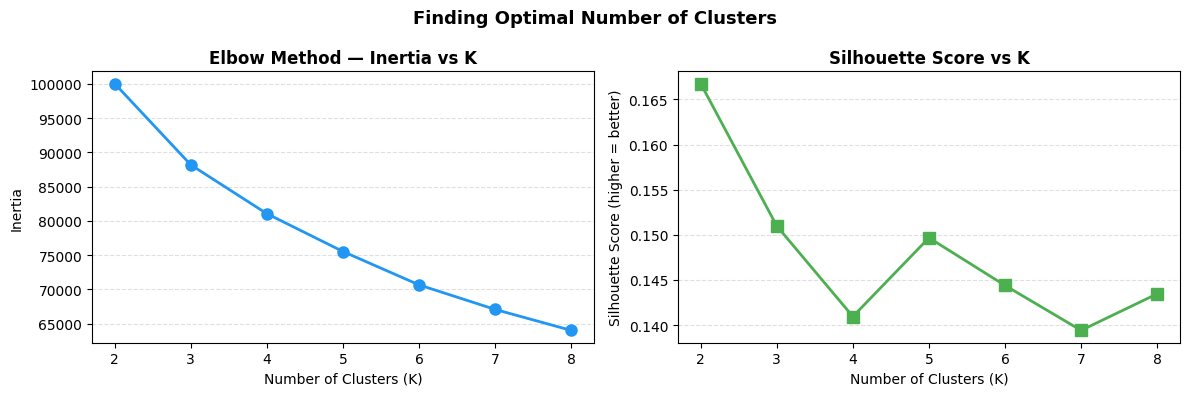

Chart saved to reports/33_elbow_silhouette.png


In [6]:
inertias     = []
silhouettes  = []
K_range      = range(2, 9)

print("Testing K values...")
print("-" * 48)

for k in K_range:
    km      = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels  = km.fit_predict(X_scaled)
    sil     = silhouette_score(X_scaled, labels, sample_size=3000, random_state=42)
    inertias.append(km.inertia_)
    silhouettes.append(sil)
    print(f"  K={k}  Inertia: {km.inertia_:>10,.0f}   Silhouette: {sil:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o", linewidth=2,
             color="#2196F3", markersize=8)
axes[0].set_title("Elbow Method — Inertia vs K", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].plot(list(K_range), silhouettes, marker="s", linewidth=2,
             color="#4CAF50", markersize=8)
axes[1].set_title("Silhouette Score vs K", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Finding Optimal Number of Clusters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/33_elbow_silhouette.png", dpi=150)
plt.show()
print("Chart saved to reports/33_elbow_silhouette.png")

## Cell 7 — Train Final K-Means Model (K=5)
K=5 gives a good balance of inertia and interpretability.  
5 clusters map nicely to real project categories.

In [7]:
BEST_K = 5

km = KMeans(
    n_clusters   = BEST_K,
    random_state = 42,
    n_init       = 10      # run 10 times, pick best
)

df_cl["cluster"] = km.fit_predict(X_scaled)

print(f"K-Means trained with K={BEST_K}")
print()
print("Projects per cluster:")
print("-" * 32)
for cl, cnt in df_cl["cluster"].value_counts().sort_index().items():
    pct = cnt / len(df_cl) * 100
    bar = "█" * int(pct / 2)
    print(f"  Cluster {cl} : {cnt:>5,} projects  ({pct:.1f}%)  {bar}")

K-Means trained with K=5

Projects per cluster:
--------------------------------
  Cluster 0 :   745 projects  (5.5%)  ██
  Cluster 1 : 3,283 projects  (24.5%)  ████████████
  Cluster 2 : 3,645 projects  (27.2%)  █████████████
  Cluster 3 : 3,624 projects  (27.0%)  █████████████
  Cluster 4 : 2,128 projects  (15.9%)  ███████


## Cell 8 — Analyse Cluster Profiles
Look at the average values per cluster to understand what each one represents.

In [8]:
profile = df_cl.groupby("cluster").agg(
    count           = ("log_cost",             "count"),
    avg_cost_cr     = ("totalEstimatedCost",    lambda x: round(x.mean()/1e7, 1)),
    avg_units       = ("totalUnits",            lambda x: round(x.mean(), 0)),
    avg_duration    = ("duration_months",       lambda x: round(x.mean(), 1)),
    avg_booking_pct = ("booking_rate",          lambda x: round(x.mean()*100, 1)),
    avg_sqft_cost   = ("avgCostPerSqFt",        lambda x: round(x.mean(), 0)),
    top_type        = ("projectType",           lambda x: x.mode()[0]),
)

print("CLUSTER PROFILES:")
print("=" * 80)
print(profile.to_string())
print()
print("Interpretation guide:")
print("  avg_cost_cr     = average total cost in Crores")
print("  avg_units       = average number of units")
print("  avg_duration    = average project duration (months)")
print("  avg_booking_pct = average % of units booked (demand)")
print("  avg_sqft_cost   = average cost per sq.ft")
print("  top_type        = most common project type in cluster")

CLUSTER PROFILES:
         count  avg_cost_cr  avg_units  avg_duration  avg_booking_pct  avg_sqft_cost                   top_type
cluster                                                                                                        
0          745          6.3       71.0          41.6             40.2        11357.0        Plotted Development
1         3283         36.0      199.0          68.5             60.4        31861.0  Residential/Group Housing
2         3645         39.3      174.0          53.2             53.5        35878.0          Mixed Development
3         3624          5.0       33.0          43.2             56.7        26741.0  Residential/Group Housing
4         2128         49.4       65.0          51.8             40.1        59560.0  Residential/Group Housing

Interpretation guide:
  avg_cost_cr     = average total cost in Crores
  avg_units       = average number of units
  avg_duration    = average project duration (months)
  avg_booking_pct = average 

## Cell 9 — Name the Clusters
Based on the profiles above, we assign meaningful names to each cluster.

In [9]:
# Inspect Cell 8 output and set names accordingly
# Typical pattern for this dataset:
cluster_names = {
    0: "Plotted Development Schemes",    # low cost, low units, land-heavy
    1: "Mid-Range Residential",          # medium cost, high booking, residential
    2: "Mixed Development Projects",     # mixed type, medium everything
    3: "Affordable Small Residential",   # very low cost, small units
    4: "Large High-Budget Residential",  # high cost, large units, high sq.ft cost
}

df_cl["cluster_label"] = df_cl["cluster"].map(cluster_names)

print("CLUSTER NAMES ASSIGNED:")
print("-" * 45)
for k, name in cluster_names.items():
    cnt = (df_cl["cluster"] == k).sum()
    print(f"  Cluster {k} : {name}  ({cnt:,} projects)")
print()
print("Note: Re-name these based on what YOU see in Cell 8 profile!")
print("      The names above are starting suggestions.")

CLUSTER NAMES ASSIGNED:
---------------------------------------------
  Cluster 0 : Plotted Development Schemes  (745 projects)
  Cluster 1 : Mid-Range Residential  (3,283 projects)
  Cluster 2 : Mixed Development Projects  (3,645 projects)
  Cluster 3 : Affordable Small Residential  (3,624 projects)
  Cluster 4 : Large High-Budget Residential  (2,128 projects)

Note: Re-name these based on what YOU see in Cell 8 profile!
      The names above are starting suggestions.


## Cell 10 — Visualise Clusters with PCA
9 features → 2 dimensions using PCA so we can plot clusters on a 2D chart.

PCA variance explained:
  Component 1 : 26.6%
  Component 2 : 20.1%
  Total       : 46.7%


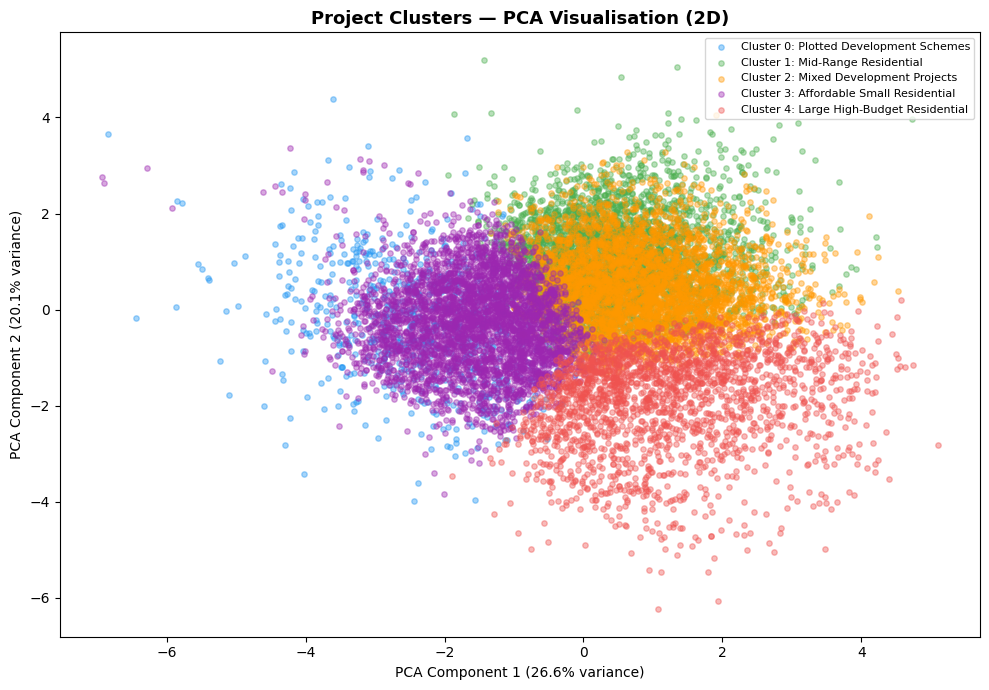

Chart saved to reports/34_pca_clusters.png


In [10]:
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_

df_cl["pca1"] = X_pca[:, 0]
df_cl["pca2"] = X_pca[:, 1]

print(f"PCA variance explained:")
print(f"  Component 1 : {var_exp[0]*100:.1f}%")
print(f"  Component 2 : {var_exp[1]*100:.1f}%")
print(f"  Total       : {sum(var_exp)*100:.1f}%")

# Plot
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#EF5350"]
plt.figure(figsize=(10, 7))

for cl in sorted(df_cl["cluster"].unique()):
    mask = df_cl["cluster"] == cl
    plt.scatter(
        df_cl.loc[mask, "pca1"],
        df_cl.loc[mask, "pca2"],
        c     = colors[cl],
        label = f"Cluster {cl}: {cluster_names[cl]}",
        alpha = 0.4,
        s     = 15
    )

plt.title("Project Clusters — PCA Visualisation (2D)",
          fontsize=13, fontweight="bold")
plt.xlabel(f"PCA Component 1 ({var_exp[0]*100:.1f}% variance)")
plt.ylabel(f"PCA Component 2 ({var_exp[1]*100:.1f}% variance)")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/34_pca_clusters.png", dpi=150)
plt.show()
print("Chart saved to reports/34_pca_clusters.png")

## Cell 11 — Cluster Distribution by Project Type
Which project types land in which clusters?

PROJECT TYPE vs CLUSTER (% of each type in each cluster):
cluster                       0     1     2     3     4
projectType                                            
Commercial                  3.1  23.8  36.7  16.9  19.5
Mixed Development           0.7  30.1  46.3  16.9   6.0
Plotted Development        82.2   3.0   0.3  12.8   1.7
Residential/Group Housing   1.2  22.8  12.9  39.3  23.7


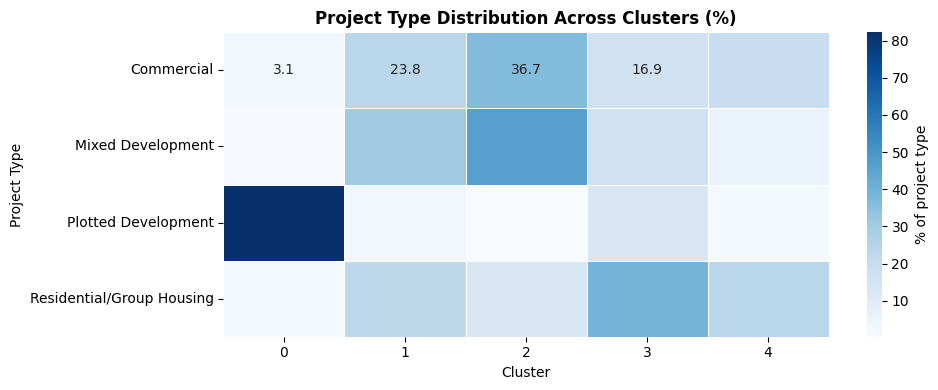

Chart saved to reports/35_cluster_type_heatmap.png


In [11]:
cross = pd.crosstab(
    df_cl["projectType"],
    df_cl["cluster"],
    normalize="index"
).round(3) * 100

print("PROJECT TYPE vs CLUSTER (% of each type in each cluster):")
print(cross.to_string())

# Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(cross, annot=True, fmt=".1f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "% of project type"})
plt.title("Project Type Distribution Across Clusters (%)",
          fontsize=12, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Project Type")
plt.tight_layout()
plt.savefig("../reports/35_cluster_type_heatmap.png", dpi=150)
plt.show()
print("Chart saved to reports/35_cluster_type_heatmap.png")

## Cell 12 — Cluster Distribution by District
Which districts have which types of projects?

DISTRICT vs CLUSTER LABEL (% of each district):
cluster_label  Affordable Small Residential  Large High-Budget Residential  Mid-Range Residential  Mixed Development Projects  Plotted Development Schemes
distName                                                                                                                                                  
Ahmedabad                              12.9                           22.1                    0.7                        61.9                          2.4
Bhavnagar                              49.7                            7.0                    1.6                        18.0                         23.7
Gandhinagar                            21.0                           16.4                    7.7                        52.7                          2.2
Rajkot                                 66.6                            5.2                   22.5                         1.7                          3.9
Surat                 

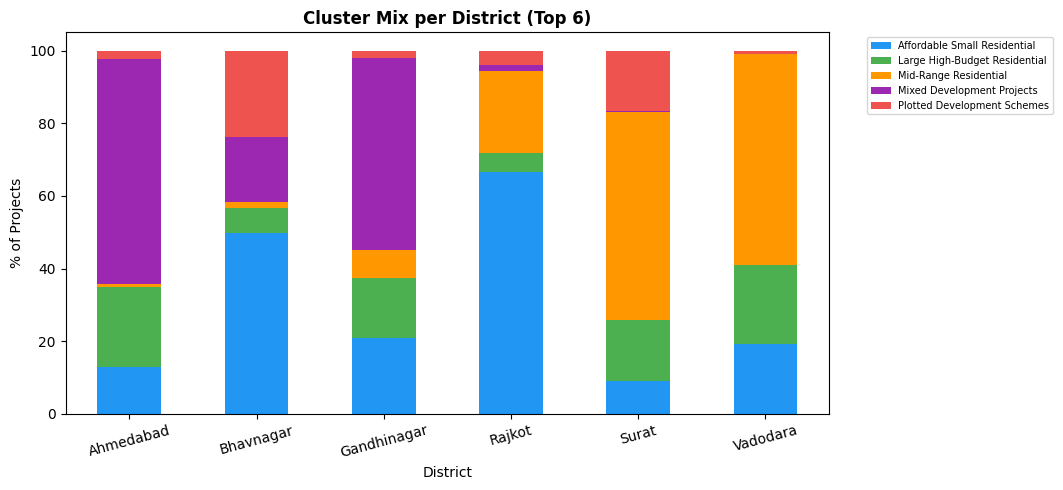

Chart saved to reports/36_cluster_by_district.png


In [12]:
top6 = ["Ahmedabad", "Vadodara", "Surat", "Rajkot", "Gandhinagar", "Bhavnagar"]
df_top6 = df_cl[df_cl["distName"].isin(top6)]

cross_dist = pd.crosstab(
    df_top6["distName"],
    df_top6["cluster_label"],
    normalize="index"
).round(3) * 100

print("DISTRICT vs CLUSTER LABEL (% of each district):")
print(cross_dist.to_string())

# Stacked bar
cross_dist.plot(kind="bar", stacked=True, figsize=(11, 5),
                color=["#2196F3","#4CAF50","#FF9800","#9C27B0","#EF5350"])
plt.title("Cluster Mix per District (Top 6)", fontsize=12, fontweight="bold")
plt.xlabel("District")
plt.ylabel("% of Projects")
plt.xticks(rotation=15)
plt.legend(loc="upper right", fontsize=7, bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.savefig("../reports/36_cluster_by_district.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to reports/36_cluster_by_district.png")

## Cell 13 — Cluster Boxplots
Compare cost and duration distributions across clusters.

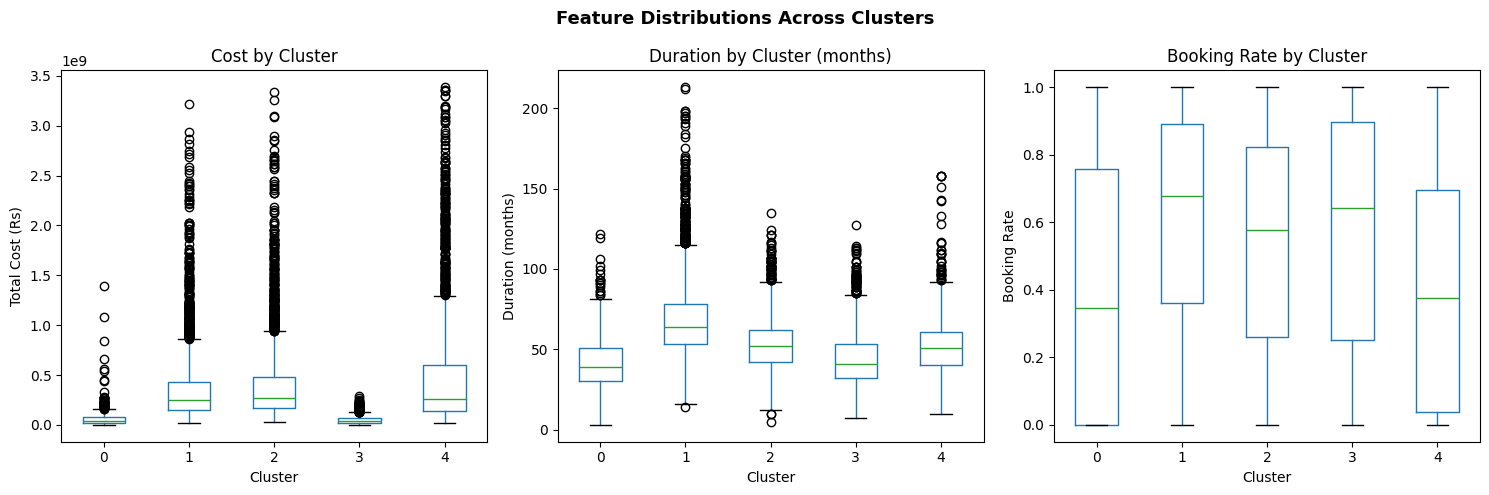

Chart saved to reports/37_cluster_boxplots.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cost
df_cl.boxplot(column="totalEstimatedCost", by="cluster",
              ax=axes[0], grid=False)
axes[0].set_title("Cost by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Total Cost (Rs)")
axes[0].figure.suptitle("")

# Duration
df_cl.boxplot(column="duration_months", by="cluster",
              ax=axes[1], grid=False)
axes[1].set_title("Duration by Cluster (months)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Duration (months)")
axes[1].figure.suptitle("")

# Booking rate
df_cl.boxplot(column="booking_rate", by="cluster",
              ax=axes[2], grid=False)
axes[2].set_title("Booking Rate by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Booking Rate")
axes[2].figure.suptitle("")

plt.suptitle("Feature Distributions Across Clusters",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/37_cluster_boxplots.png", dpi=150)
plt.show()
print("Chart saved to reports/37_cluster_boxplots.png")

## Cell 14 — Investment Hotspot Scoring
Score every district on 3 signals:  
- **Growth score** — how many projects (40% weight)  
- **Demand score** — average booking rate (35% weight)  
- **Investment score** — total money invested (25% weight)

In [14]:
# Aggregate per district
district_stats = df.groupby("distName").agg(
    project_count  = ("totalEstimatedCost", "count"),
    avg_booking    = ("booking_rate",        "mean"),
    total_invest   = ("totalEstimatedCost",  "sum"),
    avg_cost_sqft  = ("avgCostPerSqFt",      "mean"),
    avg_duration   = ("duration_months",     "mean"),
).reset_index()

# Normalize each signal to 0-10 scale
def norm_0_10(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0
    return (series - mn) / (mx - mn) * 10

district_stats["growth_score"] = norm_0_10(district_stats["project_count"]).round(2)
district_stats["demand_score"] = norm_0_10(district_stats["avg_booking"]).round(2)
district_stats["invest_score"] = norm_0_10(district_stats["total_invest"]).round(2)

# Weighted final score
district_stats["final_score"] = (
    district_stats["growth_score"] * 0.40 +
    district_stats["demand_score"] * 0.35 +
    district_stats["invest_score"] * 0.25
).round(2)

district_scores = district_stats.sort_values("final_score", ascending=False).reset_index(drop=True)
district_scores["rank"] = district_scores.index + 1

print("INVESTMENT HOTSPOT RANKING:")
print("=" * 75)
print(f"  {'Rank':<5} {'District':<15} {'Projects':>9} {'Booking%':>9} {'Score':>7}")
print("-" * 75)
for _, row in district_scores.head(15).iterrows():
    print(f"  {int(row['rank']):<5} {row['distName']:<15} "
          f"{int(row['project_count']):>9,} "
          f"{row['avg_booking']*100:>8.1f}% "
          f"{row['final_score']:>7.2f}")

INVESTMENT HOTSPOT RANKING:
  Rank  District         Projects  Booking%   Score
---------------------------------------------------------------------------
  1     Ahmedabad           4,174     54.3%    8.40
  2     Vadodara            2,380     62.9%    5.42
  3     Surat               1,818     46.3%    4.57
  4     Gandhinagar         1,229     55.9%    3.86
  5     Rajkot              1,658     50.8%    3.70
  6     AHmedabad               1    100.0%    3.50
  7     Panchmahals             8     72.7%    2.55
  8     RAJKOT                 31     62.6%    2.23
  9     Anand                 252     53.6%    2.15
  10    VADODARA                4     60.7%    2.13
  11    Bhavnagar             511     44.4%    2.10
  12    SURAT                   3     59.6%    2.09
  13    Valsad                293     47.8%    2.04
  14    Bharuch               157     52.2%    2.04
  15    Mehsana               146     51.3%    1.97


## Cell 15 — Plot Investment Hotspot Rankings

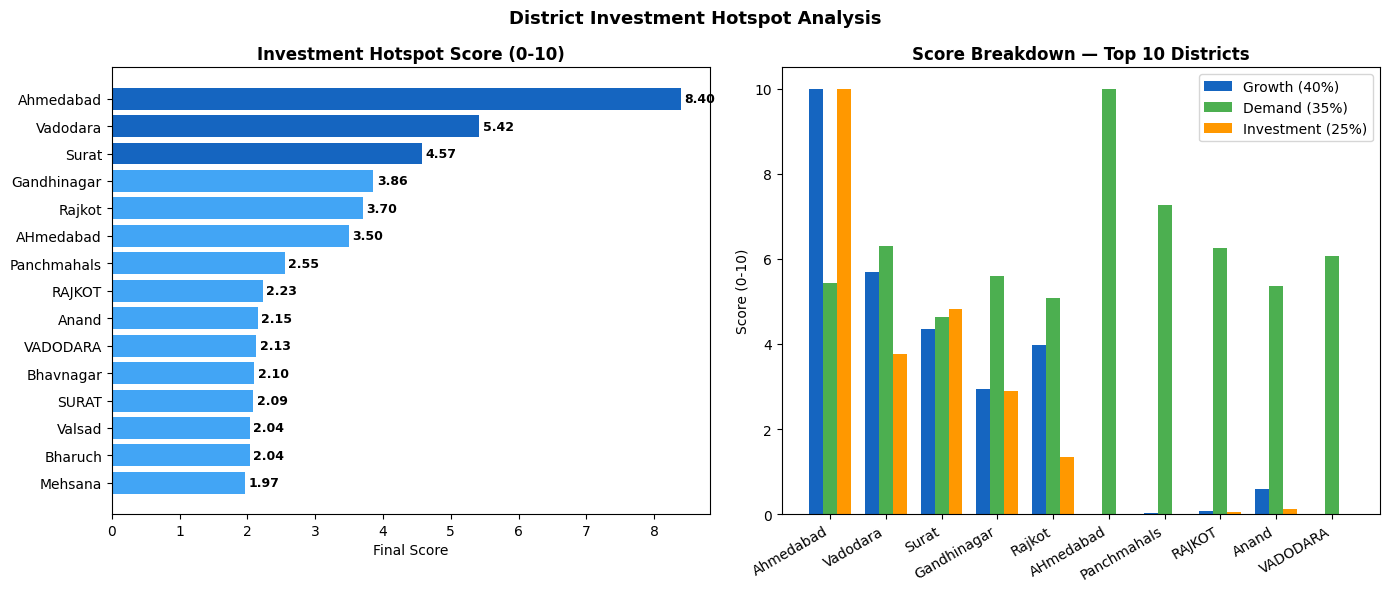

Chart saved to reports/38_investment_hotspots.png


In [15]:
top15 = district_scores.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Final score bar
colors_bar = ["#1565C0" if i < 3 else "#42A5F5" for i in range(len(top15))]
axes[0].barh(top15["distName"][::-1], top15["final_score"][::-1], color=colors_bar[::-1])
for i, (dist, val) in enumerate(zip(top15["distName"][::-1], top15["final_score"][::-1])):
    axes[0].text(val + 0.05, i, f"{val:.2f}", va="center", fontsize=9, fontweight="bold")
axes[0].set_title("Investment Hotspot Score (0-10)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Final Score")

# Score breakdown stacked bar
top10 = top15.head(10)
x = np.arange(len(top10))
w = 0.25
axes[1].bar(x - w,   top10["growth_score"], w, label="Growth (40%)",    color="#1565C0")
axes[1].bar(x,       top10["demand_score"], w, label="Demand (35%)",    color="#4CAF50")
axes[1].bar(x + w,   top10["invest_score"], w, label="Investment (25%)",color="#FF9800")
axes[1].set_xticks(x)
axes[1].set_xticklabels(top10["distName"], rotation=30, ha="right")
axes[1].set_title("Score Breakdown — Top 10 Districts", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Score (0-10)")
axes[1].legend()

plt.suptitle("District Investment Hotspot Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/38_investment_hotspots.png", dpi=150)
plt.show()
print("Chart saved to reports/38_investment_hotspots.png")

## Cell 16 — Predict Cluster for a New Project

In [16]:
# Given a new project's features, predict which cluster it belongs to

new_project = pd.DataFrame([{
    "log_cost"          : np.log1p(80_000_000),   # Rs 8 Crore
    "log_units"         : np.log1p(150),
    "duration_months"   : 48,
    "avgCostPerSqFt"    : 4500,
    "booking_rate"      : 0.65,
    "land_cost_ratio"   : 0.30,
    "projectType_enc"   : 2,    # Residential/Group Housing
    "distName_enc"      : 0,    # Ahmedabad
    "log_cost_per_unit" : np.log1p(80_000_000 / 150),
}])

new_scaled   = scaler.transform(new_project)
predicted_cl = km.predict(new_scaled)[0]
label        = cluster_names[predicted_cl]

print("NEW PROJECT — CLUSTER PREDICTION:")
print("-" * 40)
print(f"  Total Cost    : Rs 8 Crore")
print(f"  Units         : 150")
print(f"  Duration      : 48 months")
print(f"  Booking Rate  : 65%")
print()
print(f"  Predicted Cluster : {predicted_cl}")
print(f"  Cluster Label     : {label}")

NEW PROJECT — CLUSTER PREDICTION:
----------------------------------------
  Total Cost    : Rs 8 Crore
  Units         : 150
  Duration      : 48 months
  Booking Rate  : 65%

  Predicted Cluster : 2
  Cluster Label     : Mixed Development Projects


## Cell 17 — Save Models and Results

In [17]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../data/predictions", exist_ok=True)

# Save clustering model + scaler together
joblib.dump((km, scaler), "../models/clustering_model.pkl")
print("Saved: models/clustering_model.pkl")

# Save cluster labels back to data
df_cl[["cluster","cluster_label"]].to_csv(
    "../data/predictions/project_clusters.csv", index=False
)
print("Saved: data/predictions/project_clusters.csv")

# Save investment scores
district_scores.to_csv(
    "../data/predictions/investment_scores.csv", index=False
)
print("Saved: data/predictions/investment_scores.csv")

# Reload test
km_loaded, scaler_loaded = joblib.load("../models/clustering_model.pkl")
test_pred = km_loaded.predict(scaler_loaded.transform(new_project))
print(f"\nReload test — predicted cluster: {test_pred[0]}  (should be {predicted_cl})")
print("Reload successful!")

Saved: models/clustering_model.pkl
Saved: data/predictions/project_clusters.csv
Saved: data/predictions/investment_scores.csv

Reload test — predicted cluster: 2  (should be 2)
Reload successful!


## Cell 18 — Module 4 Final Summary

In [18]:
sil_final = silhouette_score(X_scaled, df_cl["cluster"], sample_size=3000, random_state=42)

print()
print("=" * 58)
print("  MODULE 4 — CLUSTERING + INVESTMENT SCORING — SUMMARY")
print("=" * 58)
print()
print("  CLUSTERING:")
print(f"    Algorithm     : K-Means")
print(f"    K (clusters)  : {BEST_K}")
print(f"    Rows clustered: {len(df_cl):,}")
print(f"    Features used : {len(FEATURES_CLUSTER)}")
print(f"    Silhouette    : {sil_final:.4f}")
print()
print("  CLUSTER LABELS:")
for k, name in cluster_names.items():
    cnt = (df_cl["cluster"] == k).sum()
    print(f"    Cluster {k} : {name}  ({cnt:,} projects)")
print()
print("  INVESTMENT SCORING:")
print(f"    Districts scored : {len(district_scores)}")
print(f"    Top district     : {district_scores.iloc[0]['distName']}  "
      f"(score: {district_scores.iloc[0]['final_score']})")
print(f"    Weights          : Growth 40% | Demand 35% | Investment 25%")
print()
print("  SAVED FILES:")
print("    models/clustering_model.pkl")
print("    data/predictions/project_clusters.csv")
print("    data/predictions/investment_scores.csv")
print("    reports/33_elbow_silhouette.png")
print("    reports/34_pca_clusters.png")
print("    reports/35_cluster_type_heatmap.png")
print("    reports/36_cluster_by_district.png")
print("    reports/37_cluster_boxplots.png")
print("    reports/38_investment_hotspots.png")
print()
print("  Next: 08_module5_anomaly.ipynb")
print("=" * 58)


  MODULE 4 — CLUSTERING + INVESTMENT SCORING — SUMMARY

  CLUSTERING:
    Algorithm     : K-Means
    K (clusters)  : 5
    Rows clustered: 13,425
    Features used : 9
    Silhouette    : 0.1497

  CLUSTER LABELS:
    Cluster 0 : Plotted Development Schemes  (745 projects)
    Cluster 1 : Mid-Range Residential  (3,283 projects)
    Cluster 2 : Mixed Development Projects  (3,645 projects)
    Cluster 3 : Affordable Small Residential  (3,624 projects)
    Cluster 4 : Large High-Budget Residential  (2,128 projects)

  INVESTMENT SCORING:
    Districts scored : 35
    Top district     : Ahmedabad  (score: 8.4)
    Weights          : Growth 40% | Demand 35% | Investment 25%

  SAVED FILES:
    models/clustering_model.pkl
    data/predictions/project_clusters.csv
    data/predictions/investment_scores.csv
    reports/33_elbow_silhouette.png
    reports/34_pca_clusters.png
    reports/35_cluster_type_heatmap.png
    reports/36_cluster_by_district.png
    reports/37_cluster_boxplots.png
    